
# Lab 3 RL - Filled Solution

This notebook is a completed solution version of the **6 exercises / 6 points** lab. The whiteboard exercises include worked calculations, and the code exercises are runnable end to end.

| Exercise | Format | Main topic | Points |
|---|---|---|---:|
| 1 | Whiteboard algorithm | Run the RL loop + compute returns + adjust the policy | 1 |
| 2 | Code | Value Iteration on FrozenLake | 1 |
| 3 | Whiteboard algorithm | Run Bellman backup / Q-learning backup by hand | 1 |
| 4 | Code | Tabular Q-learning | 1 |
| 5 | Code | DQN | 1 |
| 6 | Whiteboard adaptation + short code | REINFORCE / Actor-Critic | 1 |

The required knowledge scope follows the original slides: MDP, policy, return, Bellman equation, Value Iteration, Q-learning, DQN, REINFORCE, Actor-Critic.



# Setup


In [1]:

# If running on Colab and some libraries are missing:
# !pip install gymnasium[classic-control,toy-text] matplotlib numpy torch


In [2]:

import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque, namedtuple

import gymnasium as gym

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import torch.nn.functional as F
except ImportError:
    torch = None
    print("Torch is not installed. The DQN / REINFORCE exercises require PyTorch.")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if torch is not None:
    torch.manual_seed(SEED)

def reset_env(env):
    out = env.reset(seed=SEED)
    return out[0] if isinstance(out, tuple) else out

def step_env(env, action):
    out = env.step(action)
    if len(out) == 5:
        next_state, reward, terminated, truncated, info = out
        return next_state, reward, terminated or truncated, info
    return out



# Exercise 1 - Whiteboard algorithm: Run the RL loop and compute returns

Given the following 3x3 grid:

```text
S  .  .
.  H  .
.  .  G
```

Legend:

- `S`: start state at `(0,0)`
- `H`: hole at `(1,1)`; falling into it ends the episode, reward = `-1`
- `G`: goal at `(2,2)`; reaching it ends the episode, reward = `+1`
- Normal cells have reward = `0`
- Actions: `UP`, `DOWN`, `LEFT`, `RIGHT`
- If the agent moves outside the grid boundary, it stays in place and reward = `0`

Given the fixed policy:

```text
From every normal cell:
if moving RIGHT is possible, move RIGHT;
otherwise, move DOWN.
```

## Requirements

1. Write the trajectory from `S` under the policy above.
2. Clearly write each step: `state -> action -> next_state -> reward`.
3. Compute the return \(G_0\) with \(\gamma = 1\).
4. Compute the return \(G_0\) with \(\gamma = 0.9\).
5. Is this policy good? If not, manually adjust the policy so it reaches the goal while avoiding the hole.


## Student answer section

Trajectory from `S = (0,0)`:

| Step | State | Action | Next state | Reward |
|---:|---|---|---|---:|
| 0 | `(0,0)` | `RIGHT` | `(0,1)` | 0 |
| 1 | `(0,1)` | `RIGHT` | `(0,2)` | 0 |
| 2 | `(0,2)` | `DOWN` | `(1,2)` | 0 |
| 3 | `(1,2)` | `DOWN` | `(2,2)` | 1 |

The reward sequence is:

```text
0, 0, 0, 1
```

With \(\gamma = 1\):

$$
G_0 = 0 + 0 + 0 + 1 = 1
$$

With \(\gamma = 0.9\):

$$
G_0 = 0 + 0.9 \cdot 0 + 0.9^2 \cdot 0 + 0.9^3 \cdot 1 = 0.729
$$

From the start state, this policy reaches the goal in 4 moves and avoids the hole, so it is good for this start state. However, as a policy over all normal cells, it is not globally safe because from `(1,0)` it would move `RIGHT` into the hole `(1,1)`.

A safer hand-written policy is:

```text
(0,0): RIGHT
(0,1): RIGHT
(0,2): DOWN
(1,0): DOWN
(1,2): DOWN
(2,0): RIGHT
(2,1): RIGHT
```

This reaches the goal while avoiding the hole from all listed normal states.



# Exercise 2 - Code: Value Iteration on FrozenLake

This exercise tests **known MDPs**.

Because FrozenLake has the transition model `P(s'|s,a)`, we can use the Bellman optimality equation:


$$
V^*(s) = \max_a \sum_{s'} P(s' \mid s,a)\Bigl[r(s,a,s') + \gamma V^*(s')\Bigr]
$$


## Requirements

Complete the `value_iteration` function.

Then print:

1. `V*`
2. the corresponding greedy policy


In [3]:

def value_iteration(env, gamma=0.99, theta=1e-8, max_iter=10_000):
    nS = env.observation_space.n
    nA = env.action_space.n
    P = env.unwrapped.P

    V = np.zeros(nS)

    for it in range(max_iter):
        delta = 0
        new_V = V.copy()

        for s in range(nS):
            action_values = []

            for a in range(nA):
                q_sa = 0

                # TODO:
                # Iterate through possible transitions from state s and action a.
                # P[s][a] contains tuples: (prob, next_state, reward, done)
                for prob, next_s, reward, done in P[s][a]:
                    q_sa += prob * (reward + gamma * V[next_s] * (not done))

                action_values.append(q_sa)

            best_value = max(action_values)
            new_V[s] = best_value
            delta = max(delta, abs(V[s] - best_value))

        V = new_V

        if delta < theta:
            print(f"Converged after {it + 1} iterations")
            break

    policy = np.zeros(nS, dtype=int)

    for s in range(nS):
        action_values = []

        for a in range(nA):
            q_sa = 0
            for prob, next_s, reward, done in P[s][a]:
                q_sa += prob * (reward + gamma * V[next_s] * (not done))
            action_values.append(q_sa)

        policy[s] = int(np.argmax(action_values))

    return V, policy


env = gym.make("FrozenLake-v1", is_slippery=True)
V, policy = value_iteration(env)

print("V*:")
print(V.reshape(4, 4))

print("\nGreedy policy:")
print(policy.reshape(4, 4))

print("\nAction mapping: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP")
env.close()


Converged after 438 iterations
V*:
[[0.54202577 0.49880297 0.47069543 0.45685142]
 [0.55845081 0.         0.35834796 0.        ]
 [0.59179862 0.64307973 0.61520747 0.        ]
 [0.         0.74172037 0.86283739 0.        ]]

Greedy policy:
[[0 3 3 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]

Action mapping: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP



# Exercise 3 - Whiteboard algorithm: Run Bellman backup and Q backup by hand

Given a small MDP with 3 states:

```text
s0: start
s1: intermediate
sT: terminal
```

There are 2 actions at `s0`:

```text
action A: go to s1, reward = 0
action B: go to sT, reward = 1
```

At `s1`, there is only 1 action:

```text
action C: go to sT, reward = 3
```

`sT` is terminal, so:

$$
V(s_T) = 0
$$

Given \(\gamma = 0.9\).

## Requirement A - Run a Value backup

Assume initially:

$$
V_0(s_0)=0,\quad V_0(s_1)=0,\quad V_0(s_T)=0
$$

Compute:

1. \(V_1(s_1)\)
2. \(V_1(s_0)\)
3. What is the best action at `s0` after this backup?

## Requirement B - Run a Q-learning backup

Assume currently:

```text
Q(s0,A) = 0
Q(s0,B) = 0
Q(s1,C) = 0
```

If the agent takes the transition:

```text
s0 --A, reward=0--> s1
```

Update \(Q(s0,A)\) with:

```text
alpha = 0.5
gamma = 0.9
```

Use the Q-learning update:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha
\Bigl[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\Bigr]
$$


## Student answer section

### Requirement A

For `s1`, the only action is `C`:

$$
V_1(s_1) = 3 + 0.9V_0(s_T) = 3 + 0.9 \cdot 0 = 3
$$

For `s0`, using a synchronous Value Iteration backup from \(V_0\):

$$
Q(s_0,A) = 0 + 0.9V_0(s_1) = 0
$$

$$
Q(s_0,B) = 1 + 0.9V_0(s_T) = 1
$$

Therefore:

$$
V_1(s_0) = \max(0, 1) = 1
$$

The best action at `s0` after this synchronous backup is `B`.

If the update is done in-place and `s1` has already been updated to 3, then action `A` would have value:

$$
0 + 0.9 \cdot 3 = 2.7
$$

In that in-place case, the best action would be `A`. This is why it matters to distinguish synchronous backup from in-place update.

### Requirement B

For the transition `s0 --A, reward=0--> s1`:

$$
\max_{a'} Q(s_1,a') = Q(s_1,C) = 0
$$

The target is:

$$
r + \gamma \max_{a'} Q(s',a') = 0 + 0.9 \cdot 0 = 0
$$

The update is:

$$
Q(s_0,A) \leftarrow 0 + 0.5(0 - 0) = 0
$$

So the new value is:

$$
Q(s_0,A)=0
$$



# Exercise 4 - Code: Tabular Q-learning

This exercise tests **unknown MDPs**.

Do not use the transition model directly anymore. The agent learns by interacting with the environment.

Q-learning update:


$$
Q(s,a) \leftarrow Q(s,a) + \alpha \Bigl[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\Bigr]
$$


## Requirements

Complete / run the Q-learning code:

1. Train on FrozenLake.
2. Plot the moving average reward.
3. Print the learned policy.
4. Explain the role of epsilon-greedy.


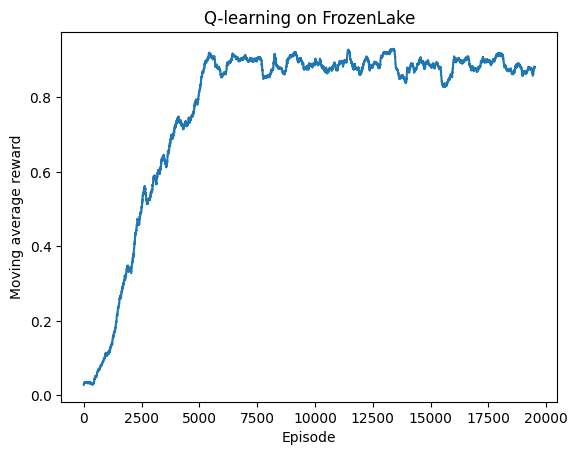

Learned greedy policy:
[[0 3 3 3]
 [0 0 3 0]
 [3 1 0 0]
 [0 2 1 0]]

Action mapping: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP


In [4]:

def epsilon_greedy(Q, state, epsilon, nA):
    if random.random() < epsilon:
        return random.randrange(nA)
    return int(np.argmax(Q[state]))

def train_q_learning(
    episodes=20_000,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.9995,
    is_slippery=True
):
    env = gym.make("FrozenLake-v1", is_slippery=is_slippery)

    nS = env.observation_space.n
    nA = env.action_space.n
    Q = np.zeros((nS, nA))

    epsilon = epsilon_start
    episode_rewards = []

    for ep in range(episodes):
        state = reset_env(env)
        total_reward = 0

        for t in range(200):
            action = epsilon_greedy(Q, state, epsilon, nA)
            next_state, reward, done, info = step_env(env, action)

            # TODO: Q-learning target
            target = reward + gamma * np.max(Q[next_state]) * (not done)

            # TODO: TD error
            td_error = target - Q[state, action]

            # TODO: update Q
            Q[state, action] += alpha * td_error

            state = next_state
            total_reward += reward

            if done:
                break

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)

    env.close()
    return Q, episode_rewards

Q, rewards = train_q_learning()

window = 500
moving_avg = np.convolve(rewards, np.ones(window) / window, mode="valid")

plt.figure()
plt.plot(moving_avg)
plt.title("Q-learning on FrozenLake")
plt.xlabel("Episode")
plt.ylabel("Moving average reward")
plt.show()

print("Learned greedy policy:")
print(np.argmax(Q, axis=1).reshape(4, 4))
print("\nAction mapping: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP")



## Exercise 4 answer: epsilon-greedy

Epsilon-greedy balances exploration and exploitation. With probability \(\epsilon\), the agent chooses a random action so it can discover better behavior. With probability \(1 - \epsilon\), it chooses the current greedy action from the Q-table.

At the beginning of training, \(\epsilon\) is high because the Q-table is mostly wrong or uninformative. Over time, \(\epsilon\) decays so the agent uses what it has learned more often while still keeping a small chance of exploration.



# Exercise 5 - Code: Deep Q-learning / DQN on CartPole

This exercise tests **function approximation**.

Tabular Q-learning is not suitable when the state is continuous or very large.  
DQN replaces the Q-table with a neural network:


$$
Q(s,a;w) \approx Q^*(s,a)
$$


Within the scope of the slides, DQN needs:

1. Q-network
2. Epsilon-greedy
3. Experience replay
4. Fixed target network
5. MSE Bellman loss

## Requirements

Run DQN on CartPole and answer:

1. What is the replay buffer used for?
2. What is the target network used for?
3. How is the loss derived from the Bellman target?


In [5]:

if torch is not None:
    class QNetwork(nn.Module):
        def __init__(self, state_dim, action_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(state_dim, 128),
                nn.ReLU(),
                nn.Linear(128, 128),
                nn.ReLU(),
                nn.Linear(128, action_dim)
            )

        def forward(self, x):
            return self.net(x)

    Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

    class ReplayBuffer:
        def __init__(self, capacity=50_000):
            self.buffer = deque(maxlen=capacity)

        def push(self, *args):
            self.buffer.append(Transition(*args))

        def sample(self, batch_size):
            batch = random.sample(self.buffer, batch_size)
            return Transition(*zip(*batch))

        def __len__(self):
            return len(self.buffer)

    def select_action(policy_net, state, epsilon, action_dim, device):
        if random.random() < epsilon:
            return random.randrange(action_dim)

        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = policy_net(state_t)
            return int(q_values.argmax(dim=1).item())


Episode 25, average return=26.0, epsilon=0.882


Episode 50, average return=23.0, epsilon=0.778


Episode 75, average return=24.6, epsilon=0.687


Episode 100, average return=29.5, epsilon=0.606


Episode 125, average return=58.0, epsilon=0.534


Episode 150, average return=58.2, epsilon=0.471


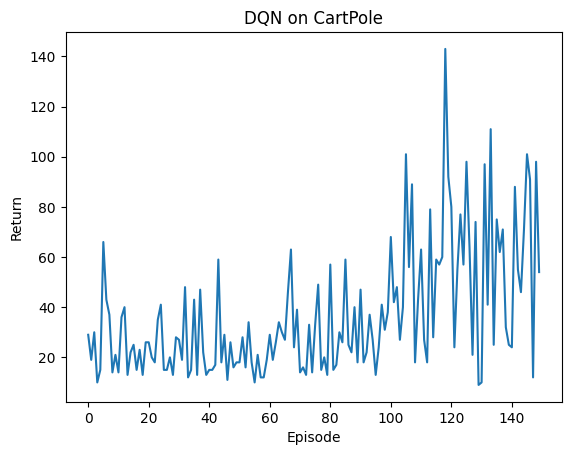

In [6]:

def train_dqn_cartpole(
    episodes=150,
    batch_size=64,
    gamma=0.99,
    lr=1e-3,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.995,
    target_update_every=10
):
    if torch is None:
        raise RuntimeError("Install torch to run the DQN exercise.")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    env = gym.make("CartPole-v1")
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy_net = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    memory = ReplayBuffer()

    epsilon = epsilon_start
    returns = []

    for ep in range(episodes):
        state = reset_env(env)
        total_reward = 0

        for t in range(500):
            action = select_action(policy_net, state, epsilon, action_dim, device)
            next_state, reward, done, info = step_env(env, action)

            memory.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward

            if len(memory) >= batch_size:
                batch = memory.sample(batch_size)

                states = torch.tensor(np.array(batch.state), dtype=torch.float32, device=device)
                actions = torch.tensor(batch.action, dtype=torch.long, device=device).unsqueeze(1)
                rewards = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
                next_states = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
                dones = torch.tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)

                q_sa = policy_net(states).gather(1, actions)

                with torch.no_grad():
                    next_q = target_net(next_states).max(dim=1, keepdim=True)[0]
                    target = rewards + gamma * next_q * (1 - dones)

                loss = F.mse_loss(q_sa, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            if done:
                break

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        returns.append(total_reward)

        if (ep + 1) % target_update_every == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if (ep + 1) % 25 == 0:
            print(f"Episode {ep+1}, average return={np.mean(returns[-25:]):.1f}, epsilon={epsilon:.3f}")

    env.close()
    return policy_net, returns

policy_net, dqn_returns = train_dqn_cartpole(episodes=150)
plt.figure()
plt.plot(dqn_returns)
plt.title("DQN on CartPole")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()



## Exercise 5 answers: DQN components

1. The replay buffer stores past transitions \((s,a,r,s',done)\). Training on random minibatches from this buffer reduces correlation between consecutive samples and makes neural-network training more stable.
2. The target network provides a slower-moving copy of the Q-network for computing Bellman targets. This prevents the target from changing every single optimizer step, which stabilizes DQN training.
3. The Bellman target is:

$$
y = r + \gamma \max_{a'} Q_{target}(s',a')
$$

for non-terminal transitions, and just \(y = r\) for terminal transitions. The loss is the mean squared error between the predicted value \(Q_{policy}(s,a)\) and this target:

$$
L = \operatorname{MSE}(Q_{policy}(s,a), y)
$$



# Exercise 6 - Whiteboard algorithm adaptation + REINFORCE code

This exercise tests **policy-based methods**.

Policy Gradient learns directly:

$$
\pi_\theta(a \mid s)
$$

REINFORCE loss:

$$
L = -\sum_t \log \pi_\theta(a_t \mid s_t)G_t
$$

Actor-Critic adds a critic \(V(s)\) and uses advantage:

$$
A_t = G_t - V(s_t)
$$

## Part A - Whiteboard: run a policy-gradient update by hand

Given one episode with 3 steps:

| t | chosen action | \(\log \pi(a_t \mid s_t)\) | discounted return \(G_t\) |
|---|---|---:|---:|
| 0 | RIGHT | -0.7 | 1.0 |
| 1 | RIGHT | -0.5 | 1.0 |
| 2 | DOWN | -1.2 | 1.0 |

REINFORCE loss:

$$
L = -\sum_t \log \pi(a_t \mid s_t)G_t
$$

Requirements:

1. Compute the loss.
2. Since \(G_t > 0\), should the probabilities of the chosen actions increase or decrease?
3. If the episode has a negative return, how would the update direction change?

## Part B - Algorithm adaptation

Assume rewards are very sparse: the agent only receives `+1` at the end of the episode if it wins, and `0` otherwise.

Students should propose 2 adjustments within the scope of the slides:

1. Should discounted returns be used? Why?
2. Should a critic/baseline be added? Why?
3. Should exploration be maintained? Why?


## Student answer section

### Part A

The loss is:

$$
L = -[(-0.7)(1.0) + (-0.5)(1.0) + (-1.2)(1.0)]
$$

$$
L = -[-2.4] = 2.4
$$

Because every \(G_t > 0\), gradient descent on this loss increases the log-probabilities of the selected actions. So the probabilities of `RIGHT`, `RIGHT`, and `DOWN` in those visited states should increase.

If the episode had a negative return, the sign of the policy-gradient contribution would reverse. Gradient descent would reduce the probability of the actions that led to that bad outcome.

### Part B

1. Discounted returns should usually be used. With sparse terminal rewards, discounting assigns more credit to actions closer to the successful terminal outcome and keeps long-horizon credit assignment numerically controlled.
2. A critic or baseline should be added because REINFORCE has high variance, especially with sparse rewards. A baseline lets the update use an advantage signal \(A_t = G_t - V(s_t)\), which keeps the direction of the policy gradient but reduces variance.
3. Exploration should be maintained. With sparse rewards, the agent may not discover successful trajectories often; if exploration collapses too early, it can get stuck repeating low-reward behavior.


In [7]:

if torch is not None:
    class PolicyNetwork(nn.Module):
        def __init__(self, state_dim, action_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(state_dim, 128),
                nn.ReLU(),
                nn.Linear(128, action_dim)
            )

        def forward(self, x):
            logits = self.net(x)
            return torch.distributions.Categorical(logits=logits)

    def compute_returns(rewards, gamma=0.99):
        returns = []
        G = 0

        for r in reversed(rewards):
            G = r + gamma * G
            returns.append(G)

        returns.reverse()
        return returns


Episode 50, average return=11.1


Episode 100, average return=14.9


Episode 150, average return=12.7


Episode 200, average return=19.7


Episode 250, average return=55.6


Episode 300, average return=42.4


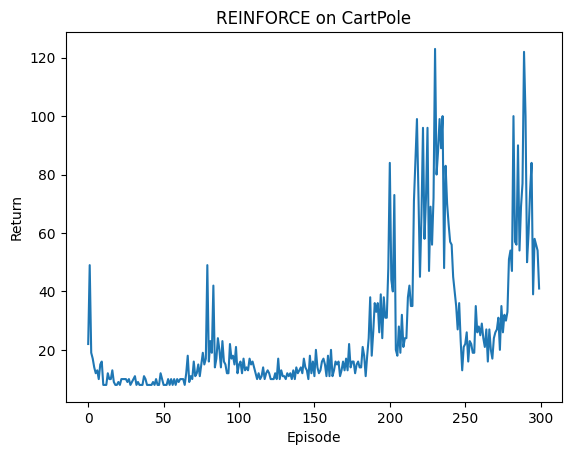

In [8]:

def train_reinforce_cartpole(episodes=300, gamma=0.99, lr=1e-2):
    if torch is None:
        raise RuntimeError("Install torch to run REINFORCE.")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    env = gym.make("CartPole-v1")
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy = PolicyNetwork(state_dim, action_dim).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    episode_returns = []

    for ep in range(episodes):
        state = reset_env(env)

        log_probs = []
        rewards = []
        total_reward = 0

        for t in range(500):
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            dist = policy(state_t)
            action = dist.sample()

            log_probs.append(dist.log_prob(action))

            next_state, reward, done, info = step_env(env, int(action.item()))

            rewards.append(reward)
            total_reward += reward
            state = next_state

            if done:
                break

        returns = torch.tensor(compute_returns(rewards, gamma), dtype=torch.float32, device=device)

        # Normalize to reduce variance.
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = 0
        for log_prob, G in zip(log_probs, returns):
            loss += -log_prob * G

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        episode_returns.append(total_reward)

        if (ep + 1) % 50 == 0:
            print(f"Episode {ep+1}, average return={np.mean(episode_returns[-50:]):.1f}")

    env.close()
    return policy, episode_returns

pg_policy, pg_returns = train_reinforce_cartpole(episodes=300)
plt.figure()
plt.plot(pg_returns)
plt.title("REINFORCE on CartPole")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()



# 6-point grading rubric

| Exercise | Criteria | Points |
|---|---|---:|
| 1 | Correctly runs the trajectory, computes returns, and adjusts the policy to avoid the hole | 1 |
| 2 | Correctly implements Value Iteration and extracts the policy | 1 |
| 3 | Correctly runs Bellman backup / Q backup and distinguishes synchronous from in-place updates | 1 |
| 4 | Correctly implements Q-learning update + epsilon-greedy and can read the policy | 1 |
| 5 | Correctly runs/explains DQN, replay buffer, target network, and Bellman loss | 1 |
| 6 | Computes REINFORCE loss, explains the update direction, and proposes critic/exploration for sparse rewards | 1 |

Total: **6 points**



# Quick review checklist before submission

You should be able to do these, not just state definitions:

1. Simulate a trajectory `state -> action -> reward -> next_state`.
2. Compute discounted returns from a reward sequence.
3. Run one Bellman backup by hand.
4. Choose an action from \(V(s)\) using one-step lookahead.
5. Choose an action from \(Q(s,a)\) using `argmax`.
6. Update one Q-learning step with concrete numbers.
7. Explain epsilon-greedy when the learned policy is currently wrong.
8. Explain the replay buffer and target network in DQN.
9. Compute REINFORCE loss from log-probabilities and returns.
10. Know when to add a critic/baseline to reduce variance.
